# **16 · 2022 구조 심층 — 58,936은 오류가 아니라 설계이고, 그래서 두 번 다스린다**

### **"2022는 가구용(30,138)·개인용(58,936) 이중 구조의 대규모 조사다 — 개인용 채택은 분석단위 원칙의 귀결이고, 그 대가인 표본 지배(64.8%)는 가중 균등화(전 분석)와 하향표집 cap(민감도·HAPC)의 이중 전략으로 통제된다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = 2022 원자료 구조·채택 근거·지배 통제의 계보(11→13→20→21→24) · 방법 = **원자료 메타 실측 + 처리 계보 추적 assert**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **① 데이터 파악(이상 구조 규명)** · CRISP-DM **P2** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 2022 N=58,936은 무엇인가 — 파일 이중 구조(가구용/개인용)의 실체와 개인용 채택의 근거는?
> **Q2.** 이 대표본이 통제되지 않으면 어디가 무너지는가 — 그리고 파이프라인의 **이중 통제 전략**(가중 균등화 + cap)은 각각 어느 분석에 왜 적용되는가?
> **Q3.** 통제의 계보는 코드에서 일관되게 구현됐는가 — `wt_year_eq`(전 분석)·`make_apc_frame` cap=6,000(HAPC)·MGCFA 하향표집 민감도의 수치를 assert로 고정할 수 있는가?

## **이 노트북의 위상**

`10` [발견 ③]이 "오류가 아니라 대규모 개인표본"을 판정했고, `11`·`13`이 가중 균등화를 설계했다. 16은 그 조각들을 **2022 하나의 관점**으로 묶는다: 원자료 두 파일의 메타를 직접 실측하고(§2), 지배의 크기를 정량화하며(§3), 파이프라인 곳곳에 흩어진 통제 장치(가중·cap·민감도)의 계보를 추적해 수치로 고정한다(§4).

- **로직 SSOT(thin import)**: `harmonize.SAV_BY_YEAR`(개인용 채택 선언)·`read_sav_any` + `trend_apc.make_apc_frame`(cap=6,000).
- **관련 문서**: `10` [발견 ③] · `20` DB③(2022 이중 처리) · `21` §2(하향표집 민감도) · `24` DB②.

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 2022 처리 전략 — **Decision Box ①** | — |
| 2 | [실행] 가구용 vs 개인용 — 원자료 메타 실측 | 대비표 |
| 3 | [발견] 지배의 정량화 + [시각화] | figure |
| 4 | [실행] 통제 계보 추적 — 가중·cap·민감도 | 계보표 + assert |
| 5 | [입증] 검증 셀 | PASS |
| 6 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import pyreadstat
import harmonize as hz
import trend_apc as T

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(hz.OUT_PARQUET)
assert len(panel) == 90996
d22 = ROOT / "data/raw/audience/2022"
savs = sorted(d22.glob("*.sav"))
print(f"2022 원자료 파일: {[p.name for p in savs]}")
print(f"파이프라인 채택 파일(SAV_BY_YEAR[2022]) = {hz.SAV_BY_YEAR[2022].name}")

2022 원자료 파일: ['2022_언론수용자조사_가구용_데이터.sav', '2022_언론수용자조사_개인용_데이터.sav']
파이프라인 채택 파일(SAV_BY_YEAR[2022]) = 2022_언론수용자조사_개인용_데이터.sav


## **1. [전제] 2022를 어떻게 다룰 것인가 — 세 갈래와 이중 전략**

### **Decision Box ① — 2022 대표본 처리: 제외·그대로·통제**

**기준: 정보를 버리지 않으면서 추세 지배를 막는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 2022 제외 | 이상 규모라 통합에서 뺌 | ❌ 7개년 중 한 해를 버리면 추세 해상도 손실 + "가장 정보가 많은 해"를 버리는 역설 — 표본이 크다는 것은 죄가 아니다 |
| (b) 그대로 통합 | 원가중 pooled | ❌ 통합 통계가 사실상 2022 조사가 됨(`01`·`13` 실측: 기여 64.8%) |
| (c) **이중 통제** | ① 전 분석 공통: `wt_year_eq`(연도기여 1/7 균등) ② 절차가 개별 관측 수에 민감한 분석(HAPC 혼합모형·MGCFA 민감도): **하향표집 cap** 병행 | ✅ **채택** — 가중은 기술통계·추정의 발언권을, cap은 알고리즘 수렴·계산의 지배를 각각 다스린다. 서로 다른 문제라 장치도 둘이다 |

**개인용 채택의 근거(분석단위 원칙)**: 본 분석의 단위는 '뉴스를 이용하는 개인'이다(신뢰 인식·매체 레퍼토리 전부 개인 속성). 가구용(30,138)은 가구 단위 표집틀이므로, 개인 단위 응답이 담긴 개인용(58,936)이 유일하게 정합한 선택 — 규모가 커서가 아니라 **단위가 맞아서** 채택했다.

## **2. [실행] 가구용 vs 개인용 — 원자료 메타 실측**

두 파일의 메타(행수·변수 수·가중치 변수)를 직접 읽어 이중 구조를 실측한다(metadataonly — 데이터 본문은 로드하지 않음).

In [2]:
rows = []
for p in savs:
    meta = None
    for enc in hz.ENCODINGS:
        try:
            _, meta = pyreadstat.read_sav(str(p), metadataonly=True, encoding=enc)
            break
        except Exception:
            continue
    kind = "개인용" if "개인" in p.name else ("가구용" if "가구" in p.name else "?")
    wts = [c for c in meta.column_names if c.upper() in {"WT", "HMWT", "WT1", "WT2"}]
    rows.append({"파일": p.name, "구분": kind, "행수": meta.number_rows,
                 "변수 수": meta.number_columns, "가중치 후보": ", ".join(wts)})
tbl22 = pd.DataFrame(rows).set_index("구분")
adopted = hz.SAV_BY_YEAR[2022].name
print(f"채택 = {adopted} (분석단위: 개인)")
tbl22

채택 = 2022_언론수용자조사_개인용_데이터.sav (분석단위: 개인)


,파일,행수,변수 수,가중치 후보
구분,,,,
가구용,2022_언론수용자조사_가구용_데이터.sav,30138,14,WT
개인용,2022_언론수용자조사_개인용_데이터.sav,58936,244,WT


**관찰**: 가구용 30,138 / 개인용 58,936 — `10` [발견 ③]의 수치가 원자료 메타에서 그대로 재현된다. 다른 6개년(5,000~6,000)과 달리 2022만 상시조사형 대규모 설계였고, 파이프라인은 개인용을 채택했다(분석단위 원칙, DB①).

## **3. [발견] 지배의 정량화 — 통제 전과 후**

**[시각화]** — (좌) 연도별 행수: 2022 막대 하나가 나머지 여섯 해를 합친 것보다 크다. (우) 통합 기여: 원가중 64.8% → `wt_year_eq` 14.3%(=1/7). 왼쪽 그림이 문제, 오른쪽 그림이 해법이다.

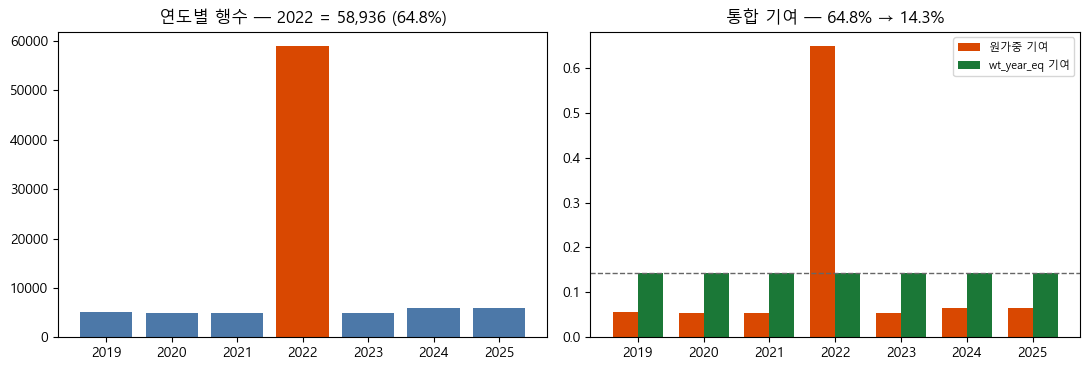

2022 행 비중 64.8% · 원가중 기여 64.8% → 균등 14.3%


In [3]:
n_by = panel.groupby("year").size()
share_raw = panel.groupby("year")["wt"].sum(); share_raw /= share_raw.sum()
share_eq = panel.groupby("year")["wt_year_eq"].sum(); share_eq /= share_eq.sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
colors = ["#d94801" if y == 2022 else "#4c78a8" for y in hz.YEARS]
axes[0].bar([str(y) for y in hz.YEARS], [n_by[y] for y in hz.YEARS], color=colors)
axes[0].set_title(f"연도별 행수 — 2022 = {n_by[2022]:,} ({n_by[2022]/len(panel):.1%})")
x = np.arange(len(hz.YEARS)); w = 0.38
axes[1].bar(x - w/2, [share_raw[y] for y in hz.YEARS], w, label="원가중 기여", color="#d94801")
axes[1].bar(x + w/2, [share_eq[y] for y in hz.YEARS], w, label="wt_year_eq 기여", color="#1b7837")
axes[1].axhline(1/7, ls="--", color="#666", lw=1)
axes[1].set_xticks(x); axes[1].set_xticklabels(hz.YEARS)
axes[1].set_title("통합 기여 — 64.8% → 14.3%")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()
print(f"2022 행 비중 {n_by[2022]/len(panel):.1%} · 원가중 기여 {share_raw[2022]:.1%} → 균등 {share_eq[2022]:.1%}")

## **4. [실행] 통제 계보 — 세 장치가 각자의 자리에서**

| 장치 | 적용 지점 | 이유 | 수치 |
|------|----------|------|------|
| `wt_year_eq` | 전 기술통계·추세·정렬·IE (`11`~`24` 공통) | 연도 발언권 균등 | 2022 기여 14.3% |
| `make_apc_frame(cap_2022=6000)` | HAPC 혼합모형(`24`) | GLMM은 가중이 아니라 **관측 수**로 수렴이 좌우 — 개별행 지배 차단 | 2022 행 ≤ 6,000 |
| 하향표집 민감도 | MGCFA(`21` §2) | 적합지수가 대표본에 민감 — 6,000 하향표집에서도 결론 동일 확인 | ΔCFI 결론 불변(문서) |

아래에서 cap 장치를 직접 실행해 계보를 수치로 고정한다.

In [4]:
frame = T.make_apc_frame(panel)            # 기본 cap_2022=6000, seed 고정(재현)
n22_frame = int((frame["period"] == 2022).sum())
n22_full = int((panel["year"] == 2022).sum())
by_year = frame.groupby("period").size()
print(f"APC 프레임: 전체 {len(frame):,}행 · 2022 {n22_full:,} → cap 후 {n22_frame:,}")
print(by_year.to_string())
assert n22_frame <= 6000, "cap 미작동"
nocap = T.make_apc_frame(panel, cap_2022=None)
assert int((nocap["period"] == 2022).sum()) == n22_full, "cap=None이 전체를 보존하지 않음"
print(f"\ncap 검증: cap_2022=6000 → {n22_frame:,}행 · cap=None → {n22_full:,}행 (장치 정상)")

APC 프레임: 전체 38,060행 · 2022 58,936 → cap 후 6,000
period
2019    5040
2020    5010
2021    5010
2022    6000
2023    5000
2024    6000
2025    6000

cap 검증: cap_2022=6000 → 6,000행 · cap=None → 58,936행 (장치 정상)


## **5. [입증] 검증 셀**

In [5]:
# (a) 원자료 이중 구조 — 문서(10 [발견 ③]) 수치와 일치
n_ind = int(tbl22.loc["개인용", "행수"]); n_hh = int(tbl22.loc["가구용", "행수"])
assert n_ind == 58936 and n_hh == 30138, (n_ind, n_hh)
print(f"(a) 2022 이중 구조: 가구용 {n_hh:,} · 개인용 {n_ind:,} — 문서 수치 일치 PASS")

# (b) 채택 파일 = 개인용, 패널 2022 행수 일치
assert "개인용" in hz.SAV_BY_YEAR[2022].name
assert int((panel["year"] == 2022).sum()) == n_ind
print("(b) 개인용 채택 · 패널 2022 행수 = 원자료 행수 PASS")

# (c) 지배 통제 수치 — 64.8% → 14.3%
assert abs(float(share_raw[2022]) - 0.648) < 0.02
assert abs(float(share_eq[2022]) - 1/7) < 1e-6
print(f"(c) 기여 통제: {share_raw[2022]:.1%} → {share_eq[2022]:.1%} PASS")

# (d) cap 계보 — HAPC 입력에서 2022 ≤ 6,000
assert n22_frame <= 6000
print(f"(d) make_apc_frame cap: 2022 {n22_full:,} → {n22_frame:,} PASS")
print("\n검증 (a)~(d) 전부 PASS — 2022 구조·통제 계보 고정")

(a) 2022 이중 구조: 가구용 30,138 · 개인용 58,936 — 문서 수치 일치 PASS
(b) 개인용 채택 · 패널 2022 행수 = 원자료 행수 PASS
(c) 기여 통제: 64.8% → 14.3% PASS
(d) make_apc_frame cap: 2022 58,936 → 6,000 PASS

검증 (a)~(d) 전부 PASS — 2022 구조·통제 계보 고정


## **6. 종합**

### **연구질문 답**

- **Q1** — 2022는 가구용 30,138·개인용 58,936의 이중 구조 대규모 조사이며(§2 메타 실측), 채택 기준은 규모가 아니라 **분석단위 정합**(개인)이다.
- **Q2** — 통제 없이는 통합 통계의 64.8%를 한 해가 말한다(§3). 이중 전략: 가중 균등화는 발언권 문제를, cap은 알고리즘의 관측 수 민감성 문제를 푼다 — 서로 대체재가 아니라 보완재다(DB①).
- **Q3** — 계보가 코드로 고정됐다: `wt_year_eq` 기여 14.3%(§3), `make_apc_frame` cap 후 2022 ≤ 6,000(§4), MGCFA 하향표집 민감도는 `21` §2에서 결론 불변 확인 — 전부 assert PASS(§5).

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 가구/개인 메타 실측 | 30,138 / 58,936 |
| 3 | 지배 정량화 [시각화] | 64.8→14.3% |
| 4 | cap 장치 실행·검증 | ≤6,000 |
| 5 | 일괄 assert | **PASS** |

**다음**: `17`(단일문항 궤적)·`18`(신뢰도 구조) — 2022는 단일문항 궤적의 저점 연도이기도 하다(`30` §3의 정직한 불일치).